# Treino Baseline V2 — Comparativo

**Projeto:** CheckAI — Classificador binário de fake news em PT-BR  
**Notebook:** `treino_baseline_v2_comparativo.ipynb`

## Objetivo
Treinar e avaliar dois modelos TF-IDF + LogReg com datasets distintos:
- **Modelo principal** (`v2_balanced`): baseline oficial da V2
- **Modelo de ablação** (`v2_size_matched`): experimento metodológico para isolar viés de comprimento

## Regras
- Feature única: `texto_principal` (nenhuma coluna estrutural como feature)
- Alvo: `label`
- Split: 80/20 com `stratify=label`, `random_state=42`
- Datasets detectados automaticamente por glob (sem hardcode de timestamp)
- Modelos V1 não são sobrescritos
- Nenhum CSV é alterado

## Referência V1
| Métrica | V1 |
|---|---|
| Acurácia | 0.8625 |
| Precisão+ | 0.9394 |
| Recall+ | 0.7750 |
| F1+ | 0.8493 |
| F1 macro | 0.8614 |
| ROC-AUC | 0.9359 |

In [20]:
import json
import re
import unicodedata
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

# --- Deteccao robusta da raiz do projeto ---
def _find_project_root() -> Path:
    cwd = Path.cwd()
    if (cwd / 'dados').is_dir():
        return cwd
    if (cwd.parent / 'dados').is_dir():
        return cwd.parent
    raise FileNotFoundError(
        f"Pasta 'dados' nao encontrada em '{cwd}' nem em '{cwd.parent}'.\n"
        "Execute o notebook a partir da raiz do projeto ou de src/."
    )

PROJECT_ROOT = _find_project_root()
DADOS_DIR    = PROJECT_ROOT / 'dados' / 'dataset_unificado' / 'final'
MODELOS_DIR  = PROJECT_ROOT / 'modelos'
MODELOS_DIR.mkdir(exist_ok=True)

print(f'CWD         : {Path.cwd()}')
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DADOS_DIR   : {DADOS_DIR}')
print(f'MODELOS_DIR : {MODELOS_DIR}')
print()
print('CSVs encontrados em DADOS_DIR:')
for csv in sorted(DADOS_DIR.glob('*.csv')):
    print(f'  {csv.name}')

# --- Constantes globais ---
SEED      = 42
TEST_SIZE = 0.2

# Parametros do pipeline (identicos nos dois modelos para comparacao justa)
TFIDF_PARAMS = dict(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.9,
    analyzer='word',
)
LOGREG_PARAMS = dict(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED,
)

# Metricas V1 para comparacao
V1_META = {
    'acuracia':     0.8625,
    'precisao_pos': 0.9394,
    'recall_pos':   0.7750,
    'f1_pos':       0.8493,
    'f1_macro':     0.8614,
    'roc_auc':      0.9359,
}

# Tokens que indicam possivel atalho (fonte, portal, estilo jornalistico, datas)
TOKENS_SUSPEITOS = [
    'afp', 'reuters', 'agencia', 'folha', 'estadao', 'globo', 'uol', 'poder',
    'bbc', 'veja', 'metropoles', 'correio', 'cartacapital', 'congresso',
    'afirmou', 'declarou', 'informou', 'divulgou', 'publicou', 'segundo',
    'conforme', 'disse', 'relatou', 'anunciou', 'revelou',
    'janeiro', 'fevereiro', 'marco', 'abril', 'maio', 'junho',
    'julho', 'agosto', 'setembro', 'outubro', 'novembro', 'dezembro',
]

# Faixas de tamanho
BINS_TAM   = [0, 50, 100, 150, 200, 300, 400, float('inf')]
LABELS_TAM = ['0_50', '50_100', '100_150', '150_200', '200_300', '300_400', '400_mais']

print()
print('Imports e configuracao OK.')


CWD         : c:\Users\offan\Desktop\ml-checkai\src
PROJECT_ROOT: c:\Users\offan\Desktop\ml-checkai
DADOS_DIR   : c:\Users\offan\Desktop\ml-checkai\dados\dataset_unificado\final
MODELOS_DIR : c:\Users\offan\Desktop\ml-checkai\modelos

CSVs encontrados em DADOS_DIR:
  dataset_final_treino_v1.csv
  dataset_final_treino_v2_balanced_2026-05-18_23-17-09.csv
  dataset_final_treino_v2_balanced_2026-05-18_23-31-48.csv
  dataset_final_treino_v2_balanced_2026-05-19_00-48-15.csv
  dataset_final_treino_v2_full_2026-05-18_23-17-09.csv
  dataset_final_treino_v2_full_2026-05-18_23-31-48.csv
  dataset_final_treino_v2_full_2026-05-19_00-48-15.csv
  dataset_final_treino_v2_size_matched_2026-05-18_23-42-41.csv

Imports e configuracao OK.


## Seção 1 — Detecção automática de datasets

In [22]:
def latest_match(candidates) -> Path:
    """Retorna o arquivo mais recente (mtime) de um iteravel de paths."""
    files = list(candidates)
    if not files:
        raise FileNotFoundError('Nenhum arquivo encontrado.')
    return max(files, key=lambda p: p.stat().st_mtime)

PATH_BALANCED     = latest_match(DADOS_DIR.glob('dataset_final_treino_v2_balanced_*.csv'))
PATH_SIZE_MATCHED = latest_match(DADOS_DIR.glob('dataset_final_treino_v2_size_matched_*.csv'))

print('Datasets detectados:')
print(f'  Principal  (balanced):     {PATH_BALANCED.name}')
print(f'  Ablacao    (size_matched): {PATH_SIZE_MATCHED.name}')


Datasets detectados:
  Principal  (balanced):     dataset_final_treino_v2_balanced_2026-05-19_00-48-15.csv
  Ablacao    (size_matched): dataset_final_treino_v2_size_matched_2026-05-18_23-42-41.csv


## Seção 2 — Funções auxiliares

In [23]:
# ── Limpeza textual ──────────────────────────────────────────────────────────
def limpar_texto(texto: str) -> str:
    if not isinstance(texto, str):
        return ''
    texto = unicodedata.normalize('NFKC', texto)
    texto = texto.lower()
    texto = re.sub(r'https?://\S+', ' ', texto)   # URLs
    texto = re.sub(r'[^\w\s]', ' ', texto)         # pontuação
    texto = re.sub(r'\d+', ' ', texto)             # números
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()


# ── Faixa de tamanho ────────────────────────────────────────────────────────
def atribuir_faixa(n: int) -> str:
    for i in range(len(BINS_TAM) - 1):
        if BINS_TAM[i] <= n < BINS_TAM[i + 1]:
            return LABELS_TAM[i]
    return LABELS_TAM[-1]


# ── Pipeline factory ─────────────────────────────────────────────────────────
def make_pipeline() -> Pipeline:
    return Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LogisticRegression(**LOGREG_PARAMS)),
    ])


# ── Avaliação de métricas ────────────────────────────────────────────────────
def avaliar_modelo(pipe, X_test, y_test, nome: str) -> dict:
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    metricas = {
        'acuracia':     round(accuracy_score(y_test, y_pred), 4),
        'precisao_pos': round(precision_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'recall_pos':   round(recall_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'f1_pos':       round(f1_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'f1_macro':     round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'roc_auc':      round(roc_auc_score(y_test, y_prob), 4),
    }

    SEP = '-' * 55
    print(f'\n{SEP}')
    print(f'Métricas — {nome}')
    print(SEP)
    for k, v in metricas.items():
        print(f'  {k:<15}: {v}')
    print()
    print('Matriz de confusão:')
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm,
        index=['Real 0','Real 1'],
        columns=['Pred 0','Pred 1']
    )
    print(cm_df.to_string())
    print()
    print('Classification report:')
    print(classification_report(y_test, y_pred,
          target_names=['fake/misleading','real/verdadeiro'], zero_division=0))

    return metricas, y_pred, y_prob


# ── Análise de erros ─────────────────────────────────────────────────────────
def analisar_erros(df_test: pd.DataFrame, y_pred, nome: str):
    df = df_test.copy()
    df['pred']  = y_pred
    df['erro']  = df['label'] != df['pred']
    df['faixa'] = df['tamanho_chars'].apply(atribuir_faixa)
    # usa faixa_tamanho do dataset se disponível, senão usa a calculada
    if 'faixa_tamanho' in df.columns:
        df['faixa'] = df['faixa_tamanho']

    n_erros = df['erro'].sum()
    print(f'\nErros totais no teste: {n_erros}/{len(df)} ({100*n_erros/len(df):.1f}%)')

    def tabela_erros(col, titulo):
        t = df.groupby(col)['erro'].agg(['sum','count'])
        t.columns = ['erros','total']
        t['taxa_%'] = (100 * t['erros'] / t['total']).round(1)
        print(f'\n[Erros por {titulo}]')
        print(t.sort_values('taxa_%', ascending=False).to_string())

    tabela_erros('label_detalhe', 'label_detalhe')
    tabela_erros('origem_qualidade', 'origem_qualidade')
    tabela_erros('portal_origem', 'portal_origem')
    tabela_erros('faixa', 'faixa_tamanho')

    # Tamanho médio: acertos vs erros
    print('\n[Tamanho médio/mediana — acertos vs erros]')
    for correto in [True, False]:
        sub = df[~df['erro'] if correto else df['erro']]['tamanho_chars']
        label = 'acertos' if correto else 'erros  '
        if len(sub) > 0:
            print(f'  {label}: média={sub.mean():.0f}  mediana={sub.median():.0f}  n={len(sub)}')


# ── Análise de coeficientes ──────────────────────────────────────────────────
def analisar_coeficientes(pipe, nome: str, top_n: int = 20):
    vocab      = pipe.named_steps['tfidf'].get_feature_names_out()
    coef       = pipe.named_steps['clf'].coef_[0]
    idx_pos    = np.argsort(coef)[::-1][:top_n]
    idx_neg    = np.argsort(coef)[:top_n]

    print(f'\n[Top {top_n} tokens — label=1 (real/verdadeiro)]')
    for i in idx_pos:
        suspeito = '*SUSPEITO*' if any(s in vocab[i] for s in TOKENS_SUSPEITOS) else ''
        print(f'  {vocab[i]:<35} {coef[i]:+.4f}  {suspeito}')

    print(f'\n[Top {top_n} tokens — label=0 (fake/misleading)]')
    for i in idx_neg:
        suspeito = '*SUSPEITO*' if any(s in vocab[i] for s in TOKENS_SUSPEITOS) else ''
        print(f'  {vocab[i]:<35} {coef[i]:+.4f}  {suspeito}')

    # Conta suspeitos no top-40
    top40 = set(vocab[i] for i in list(idx_pos) + list(idx_neg))
    suspeitos_encontrados = [
        t for t in top40 if any(s in t for s in TOKENS_SUSPEITOS)
    ]
    if suspeitos_encontrados:
        print(f'\n  ⚠  Tokens suspeitos no top-{top_n*2}: {suspeitos_encontrados}')
    else:
        print(f'\n  OK: nenhum token suspeito de fonte/estilo no top-{top_n*2}.')
    return suspeitos_encontrados


print('Funções auxiliares definidas.')

Funções auxiliares definidas.


In [24]:
def plot_confusion_matrix(y_true, y_pred, titulo: str):
    cm = confusion_matrix(y_true, y_pred)
    labels = ['fake/misleading (0)', 'real/verdadeiro (1)']
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        linewidths=0.5, ax=ax,
    )
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f'  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
    print(f'  Falsos negativos (fake classificado como real): {fn}')
    print(f'  Falsos positivos (real classificado como fake): {fp}')


## Seção 3.1 — Modelo principal: v2_balanced

Dataset principal da V2. Balanceado 1:1, deduplicado, sem viés de tamanho controlado.  
Este é o **baseline oficial da V2**.

In [25]:
# ── Carrega e prepara ────────────────────────────────────────────────────────
df_bal = pd.read_csv(PATH_BALANCED, encoding='utf-8')
print(f'Dataset: {PATH_BALANCED.name}')
print(f'Shape: {df_bal.shape}')
print(f'label=0: {(df_bal.label==0).sum()}  label=1: {(df_bal.label==1).sum()}')
print()

df_bal['texto_limpo'] = df_bal['texto_principal'].apply(limpar_texto)

X_bal = df_bal['texto_limpo'].values
y_bal = df_bal['label'].values

X_bal_train, X_bal_test, y_bal_train, y_bal_test, idx_bal_train, idx_bal_test = \
    train_test_split(
        X_bal, y_bal, df_bal.index.values,
        test_size=TEST_SIZE, random_state=SEED, stratify=y_bal
    )

print(f'Treino: {len(X_bal_train)}  |  Teste: {len(X_bal_test)}')
print(f'Treino label=0/1: {(y_bal_train==0).sum()}/{(y_bal_train==1).sum()}')
print(f'Teste  label=0/1: {(y_bal_test==0).sum()}/{(y_bal_test==1).sum()}')

# ── Treina ────────────────────────────────────────────────────────────────────
pipe_bal = make_pipeline()
pipe_bal.fit(X_bal_train, y_bal_train)
print(f'\nFeatures TF-IDF: {len(pipe_bal.named_steps["tfidf"].get_feature_names_out())}')

# Subconjunto de teste com metadados
df_bal_test = df_bal.loc[idx_bal_test].copy()

Dataset: dataset_final_treino_v2_balanced_2026-05-19_00-48-15.csv
Shape: (508, 11)
label=0: 254  label=1: 254

Treino: 406  |  Teste: 102
Treino label=0/1: 203/203
Teste  label=0/1: 51/51

Features TF-IDF: 1858


In [26]:
metricas_bal, y_bal_pred, y_bal_prob = avaliar_modelo(
    pipe_bal, X_bal_test, y_bal_test, 'v2_balanced (baseline oficial)'
)


-------------------------------------------------------
Métricas — v2_balanced (baseline oficial)
-------------------------------------------------------
  acuracia       : 0.902
  precisao_pos   : 0.9362
  recall_pos     : 0.8627
  f1_pos         : 0.898
  f1_macro       : 0.9018
  roc_auc        : 0.9708

Matriz de confusão:
        Pred 0  Pred 1
Real 0      48       3
Real 1       7      44

Classification report:
                 precision    recall  f1-score   support

fake/misleading       0.87      0.94      0.91        51
real/verdadeiro       0.94      0.86      0.90        51

       accuracy                           0.90       102
      macro avg       0.90      0.90      0.90       102
   weighted avg       0.90      0.90      0.90       102



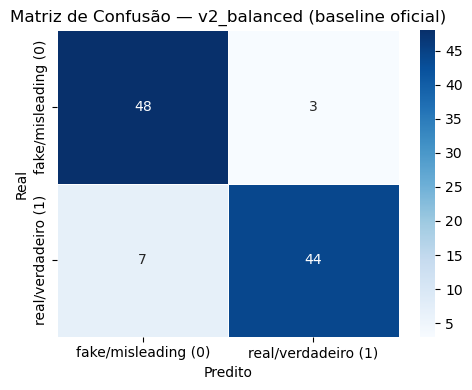

  TN=48  FP=3  FN=7  TP=44
  Falsos negativos (fake classificado como real): 7
  Falsos positivos (real classificado como fake): 3


In [27]:
plot_confusion_matrix(y_bal_test, y_bal_pred, 'Matriz de Confusão — v2_balanced (baseline oficial)')


In [28]:
print('=== Análise de erros — v2_balanced ===')
analisar_erros(df_bal_test, y_bal_pred, 'v2_balanced')

=== Análise de erros — v2_balanced ===

Erros totais no teste: 10/102 (9.8%)

[Erros por label_detalhe]
                  erros  total  taxa_%
label_detalhe                         
GFC_VERDADEIRO        2      3    66.7
NOTICIA_REAL          5     48    10.4
FALSO                 2     32     6.2
ENGANOSO              1     17     5.9
FORA_DE_CONTEXTO      0      2     0.0

[Erros por origem_qualidade]
                  erros  total  taxa_%
origem_qualidade                      
ROTULO_ASSUMIDO       5     48    10.4
ROTULO_FORTE          5     54     9.3

[Erros por portal_origem]
                     erros  total  taxa_%
portal_origem                            
CONGRESSO_EM_FOCO        1      3    33.3
PODER360                 1      4    25.0
CARTACAPITAL             1      4    25.0
UOL_NOTÍCIAS             1      7    14.3
AOS_FATOS                2     15    13.3
AFP_CHECAMOS             1      8    12.5
CORREIO_BRAZILIENSE      1      8    12.5
ESTADÃO                  1     1

In [29]:
print('=== Coeficientes — v2_balanced ===')
suspeitos_bal = analisar_coeficientes(pipe_bal, 'v2_balanced', top_n=20)

=== Coeficientes — v2_balanced ===

[Top 20 tokens — label=1 (real/verdadeiro)]
  mais                                +1.4400  
  leia                                +1.3329  
  leia mais                           +1.3329  
  da                                  +1.3250  
  ex                                  +1.2666  
  flávio                              +1.1436  
  vorcaro                             +0.9717  
  na                                  +0.8887  
  entre                               +0.8837  
  de                                  +0.8610  
  filme                               +0.8293  
  sobre                               +0.8090  
  flávio bolsonaro                    +0.8086  
  pré                                 +0.7686  
  pl                                  +0.7672  
  ao                                  +0.7645  
  zema                                +0.6745  
  ministro                            +0.6290  
  projeto                             +0.6101  
  câmara

## Seção 3.2 — Modelo de ablação: v2_size_matched

Dataset com controle de comprimento: mesmo número de amostras label=0 e label=1 por faixa de tamanho.  
**Este não é o modelo oficial.** Serve exclusivamente para verificar se o modelo principal
usa comprimento do texto como atalho (shortcut learning).

> Se o desempenho cair significativamente aqui, o viés de comprimento é um risco real.

In [30]:
df_sm = pd.read_csv(PATH_SIZE_MATCHED, encoding='utf-8')
print(f'Dataset: {PATH_SIZE_MATCHED.name}')
print(f'Shape: {df_sm.shape}')
print(f'label=0: {(df_sm.label==0).sum()}  label=1: {(df_sm.label==1).sum()}')
print()

df_sm['texto_limpo'] = df_sm['texto_principal'].apply(limpar_texto)

X_sm = df_sm['texto_limpo'].values
y_sm = df_sm['label'].values

X_sm_train, X_sm_test, y_sm_train, y_sm_test, idx_sm_train, idx_sm_test = \
    train_test_split(
        X_sm, y_sm, df_sm.index.values,
        test_size=TEST_SIZE, random_state=SEED, stratify=y_sm
    )

print(f'Treino: {len(X_sm_train)}  |  Teste: {len(X_sm_test)}')
print(f'Treino label=0/1: {(y_sm_train==0).sum()}/{(y_sm_train==1).sum()}')
print(f'Teste  label=0/1: {(y_sm_test==0).sum()}/{(y_sm_test==1).sum()}')

# min_df=2 pode ser agressivo com ~116 amostras — nota metodológica
pipe_sm = make_pipeline()
pipe_sm.fit(X_sm_train, y_sm_train)
print(f'\nFeatures TF-IDF: {len(pipe_sm.named_steps["tfidf"].get_feature_names_out())}')
print('Nota: min_df=2 num corpus pequeno (~116 treino) é conservador — esperar vocabulário reduzido.')

df_sm_test = df_sm.loc[idx_sm_test].copy()

Dataset: dataset_final_treino_v2_size_matched_2026-05-18_23-42-41.csv
Shape: (146, 12)
label=0: 73  label=1: 73

Treino: 116  |  Teste: 30
Treino label=0/1: 58/58
Teste  label=0/1: 15/15

Features TF-IDF: 456
Nota: min_df=2 num corpus pequeno (~116 treino) é conservador — esperar vocabulário reduzido.


In [31]:
metricas_sm, y_sm_pred, y_sm_prob = avaliar_modelo(
    pipe_sm, X_sm_test, y_sm_test, 'v2_size_matched (ablação)'
)


-------------------------------------------------------
Métricas — v2_size_matched (ablação)
-------------------------------------------------------
  acuracia       : 0.8667
  precisao_pos   : 0.9231
  recall_pos     : 0.8
  f1_pos         : 0.8571
  f1_macro       : 0.8661
  roc_auc        : 0.9644

Matriz de confusão:
        Pred 0  Pred 1
Real 0      14       1
Real 1       3      12

Classification report:
                 precision    recall  f1-score   support

fake/misleading       0.82      0.93      0.88        15
real/verdadeiro       0.92      0.80      0.86        15

       accuracy                           0.87        30
      macro avg       0.87      0.87      0.87        30
   weighted avg       0.87      0.87      0.87        30



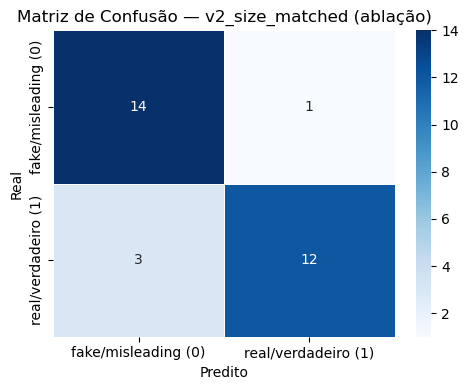

  TN=14  FP=1  FN=3  TP=12
  Falsos negativos (fake classificado como real): 3
  Falsos positivos (real classificado como fake): 1


In [32]:
plot_confusion_matrix(y_sm_test, y_sm_pred, 'Matriz de Confusão — v2_size_matched (ablação)')


In [33]:
print('=== Análise de erros — v2_size_matched ===')
analisar_erros(df_sm_test, y_sm_pred, 'v2_size_matched')

=== Análise de erros — v2_size_matched ===

Erros totais no teste: 4/30 (13.3%)

[Erros por label_detalhe]
                  erros  total  taxa_%
label_detalhe                         
GFC_VERDADEIRO        2      4    50.0
ENGANOSO              1      3    33.3
NOTICIA_REAL          1     11     9.1
FALSO                 0     10     0.0
FORA_DE_CONTEXTO      0      2     0.0

[Erros por origem_qualidade]
                  erros  total  taxa_%
origem_qualidade                      
ROTULO_FORTE          3     19    15.8
ROTULO_ASSUMIDO       1     11     9.1

[Erros por portal_origem]
                     erros  total  taxa_%
portal_origem                            
PODER360                 1      3    33.3
UOL_NOTÍCIAS             1      3    33.3
ESTADÃO                  1      4    25.0
AOS_FATOS                1      7    14.3
AFP_CHECAMOS             0      1     0.0
BOATOS.ORG               0      1     0.0
CARTACAPITAL             0      2     0.0
CORREIO_BRAZILIENSE      0   

In [34]:
print('=== Coeficientes — v2_size_matched ===')
suspeitos_sm = analisar_coeficientes(pipe_sm, 'v2_size_matched', top_n=20)

=== Coeficientes — v2_size_matched ===

[Top 20 tokens — label=1 (real/verdadeiro)]
  flávio                              +0.7399  
  ministro                            +0.6273  
  fui                                 +0.5589  
  entre                               +0.5545  
  da                                  +0.5330  
  milhões                             +0.5279  
  flávio bolsonaro                    +0.4915  
  milhões de                          +0.4821  
  leia mais                           +0.4219  
  leia                                +0.4219  
  ex                                  +0.4205  
  master                              +0.4112  
  presidência                         +0.4097  
  do                                  +0.3551  
  mais                                +0.3520  
  de lula                             +0.3467  
  de flávio                           +0.3427  
  disputa                             +0.3357  
  projeto                             +0.3348  
  vo

## Seção 4 — Comparação: V1 vs V2_balanced vs V2_size_matched

In [35]:
SEP = '=' * 70
print(SEP)
print('TABELA COMPARATIVA DE MÉTRICAS')
print(SEP)

modelos = {
    'V1 (referência)':       V1_META,
    'V2_balanced (oficial)': metricas_bal,
    'V2_size_matched (abl)': metricas_sm,
}

metricas_keys = ['acuracia', 'precisao_pos', 'recall_pos', 'f1_pos', 'f1_macro', 'roc_auc']
header = f"{'Métrica':<18}" + ''.join(f"{k:<26}" for k in modelos)
print(header)
print('-' * len(header))

for m in metricas_keys:
    row = f'{m:<18}'
    v1_val = V1_META[m]
    for nome, met in modelos.items():
        val = met[m]
        delta = f'({val - v1_val:+.4f} vs V1)' if nome != 'V1 (referência)' else ''
        row += f'{val:<12} {delta:<14}'
    print(row)

print()

# Drop de desempenho balanced vs size_matched
print('Drop de desempenho (balanced → size_matched):')
for m in metricas_keys:
    delta = metricas_sm[m] - metricas_bal[m]
    sinal = 'QUEDA' if delta < -0.03 else ('leve' if delta < 0 else 'ganho')
    print(f'  {m:<18}: {delta:+.4f}  [{sinal}]')

TABELA COMPARATIVA DE MÉTRICAS
Métrica           V1 (referência)           V2_balanced (oficial)     V2_size_matched (abl)     
------------------------------------------------------------------------------------------------
acuracia          0.8625                     0.902        (+0.0395 vs V1)0.8667       (+0.0042 vs V1)
precisao_pos      0.9394                     0.9362       (-0.0032 vs V1)0.9231       (-0.0163 vs V1)
recall_pos        0.775                      0.8627       (+0.0877 vs V1)0.8          (+0.0250 vs V1)
f1_pos            0.8493                     0.898        (+0.0487 vs V1)0.8571       (+0.0078 vs V1)
f1_macro          0.8614                     0.9018       (+0.0404 vs V1)0.8661       (+0.0047 vs V1)
roc_auc           0.9359                     0.9708       (+0.0349 vs V1)0.9644       (+0.0285 vs V1)

Drop de desempenho (balanced → size_matched):
  acuracia          : -0.0353  [QUEDA]
  precisao_pos      : -0.0131  [leve]
  recall_pos        : -0.0627  [QUEDA]


In [36]:
# Sobreposição de top tokens entre os dois modelos
def top_tokens(pipe, n=30):
    vocab = pipe.named_steps['tfidf'].get_feature_names_out()
    coef  = pipe.named_steps['clf'].coef_[0]
    top_p = set(vocab[i] for i in np.argsort(coef)[::-1][:n])
    top_n = set(vocab[i] for i in np.argsort(coef)[:n])
    return top_p, top_n

tp_bal, tn_bal = top_tokens(pipe_bal)
tp_sm,  tn_sm  = top_tokens(pipe_sm)

sobrep_pos = tp_bal & tp_sm
sobrep_neg = tn_bal & tn_sm

print('Sobreposição de top-30 tokens entre balanced e size_matched:')
print(f'  Positivos (label=1) compartilhados: {len(sobrep_pos)}/30 → {sorted(sobrep_pos)}')
print(f'  Negativos (label=0) compartilhados: {len(sobrep_neg)}/30 → {sorted(sobrep_neg)}')

print()
print('Tokens suspeitos encontrados:')
print(f'  balanced    : {suspeitos_bal or "nenhum"}')
print(f'  size_matched: {suspeitos_sm  or "nenhum"}')

Sobreposição de top-30 tokens entre balanced e size_matched:
  Positivos (label=1) compartilhados: 12/30 → ['da', 'do', 'entre', 'ex', 'flávio', 'flávio bolsonaro', 'leia', 'leia mais', 'mais', 'ministro', 'projeto', 'vorcaro']
  Negativos (label=0) compartilhados: 12/30 → ['alexandre', 'alexandre de', 'contra covid', 'covid', 'de moraes', 'dengue', 'eleições', 'haddad', 'mst', 'que', 'vacina', 'vídeo']

Tokens suspeitos encontrados:
  balanced    : nenhum
  size_matched: nenhum


## Seção 5 — Conclusão e recomendação metodológica

In [37]:
SEP = '=' * 70
print(SEP)
print('CONCLUSÃO — 6 PERGUNTAS METODOLÓGICAS')
print(SEP)

# 1. V2_balanced melhor que V1?
delta_f1 = metricas_bal['f1_macro'] - V1_META['f1_macro']
delta_auc = metricas_bal['roc_auc']  - V1_META['roc_auc']
if delta_f1 > 0.01:
    q1 = f'SIM — F1 macro subiu {delta_f1:+.4f} (V2={metricas_bal["f1_macro"]:.4f} vs V1={V1_META["f1_macro"]:.4f}).'
elif delta_f1 < -0.01:
    q1 = f'NÃO — F1 macro caiu {delta_f1:+.4f}. Investigar overfitting ou qualidade do dataset.'
else:
    q1 = f'EMPATE TÉCNICO — F1 macro delta={delta_f1:+.4f}. Sem melhora significativa.'

# 2. Queda no size_matched?
drop_f1 = metricas_sm['f1_macro'] - metricas_bal['f1_macro']
if drop_f1 < -0.10:
    q2 = f'SIM, QUEDA SIGNIFICATIVA — F1 macro caiu {drop_f1:+.4f}. Confirma dependência de viés de tamanho.'
elif drop_f1 < -0.03:
    q2 = f'QUEDA MODERADA — F1 macro caiu {drop_f1:+.4f}. Possível viés parcial de tamanho.'
else:
    q2 = f'QUEDA MÍNIMA — F1 macro delta={drop_f1:+.4f}. Modelo parece robusto ao controle de tamanho.'

# 3. Evidência de shortcut learning por comprimento?
if suspeitos_bal and drop_f1 < -0.05:
    q3 = 'SIM — Tokens suspeitos nos coeficientes E queda no size_matched. Risco real de shortcut.'
elif drop_f1 < -0.10:
    q3 = 'PROVÁVEL — Queda significativa no size_matched sem tokens suspeitos óbvios. TF-IDF pode capturar comprimento implicitamente.'
elif suspeitos_bal:
    q3 = 'PARCIAL — Tokens suspeitos encontrados mas queda no size_matched é pequena.'
else:
    q3 = 'NÃO EVIDENCIADO — Nenhum token suspeito e queda mínima no size_matched.'

# 4. Riscos metodológicos
q4 = """Principais riscos remanescentes:
   a) Concentração de portais: AOS_FATOS e FOLHA_PODER dominam as respectivas classes.
   b) Desequilíbrio de comprimento estrutural: claims GFC (label=0) são curtos;
      notícias RSS (label=1) são mais longas — não totalmente eliminável sem oversampling.
   c) Domínio político: dataset concentrado em política eleitoral brasileira 2022-2024.
   d) Volume pequeno (507 balanced): generalizações devem ser cautelosas.
   e) min_df=2 no corpus de ablação (~116 treino): vocabulário reduzido, possível underfitting."""

# 5. Modelo oficial V2?
q5 = ('v2_balanced — maior volume, pipeline idêntico ao V1, metodologicamente defensável para TCC. '
       'Reportar sempre com v2_size_matched como experimento de robustez.')

# 6. Size_matched como ablação?
q6 = ('SIM — manter apenas como experimento de ablação. Não usar em produção. '
       'Serve para documentar no TCC que o impacto do viés de comprimento foi investigado.')

perguntas = [
    ('1. V2_balanced melhor que V1?',                          q1),
    ('2. Queda significativa no size_matched?',                q2),
    ('3. Modelo usa comprimento como atalho?',                 q3),
    ('4. Riscos metodológicos remanescentes?',                 q4),
    ('5. Modelo oficial da V2?',                              q5),
    ('6. Size_matched mantido como ablação?',                  q6),
]

for pergunta, resposta in perguntas:
    print(f'\n{pergunta}')
    print(f'  → {resposta}')

CONCLUSÃO — 6 PERGUNTAS METODOLÓGICAS

1. V2_balanced melhor que V1?
  → SIM — F1 macro subiu +0.0404 (V2=0.9018 vs V1=0.8614).

2. Queda significativa no size_matched?
  → QUEDA MODERADA — F1 macro caiu -0.0357. Possível viés parcial de tamanho.

3. Modelo usa comprimento como atalho?
  → NÃO EVIDENCIADO — Nenhum token suspeito e queda mínima no size_matched.

4. Riscos metodológicos remanescentes?
  → Principais riscos remanescentes:
   a) Concentração de portais: AOS_FATOS e FOLHA_PODER dominam as respectivas classes.
   b) Desequilíbrio de comprimento estrutural: claims GFC (label=0) são curtos;
      notícias RSS (label=1) são mais longas — não totalmente eliminável sem oversampling.
   c) Domínio político: dataset concentrado em política eleitoral brasileira 2022-2024.
   d) Volume pequeno (507 balanced): generalizações devem ser cautelosas.
   e) min_df=2 no corpus de ablação (~116 treino): vocabulário reduzido, possível underfitting.

5. Modelo oficial da V2?
  → v2_balanced — 

## Seção 6 — Salvamento de modelos e metadados

In [38]:
TS = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

def salvar_modelo(pipe, nome_base: str, path_dataset: Path,
                  df_full: pd.DataFrame, n_treino: int, n_teste: int,
                  y_treino, y_teste, metricas: dict):

    path_joblib = MODELOS_DIR / f'{nome_base}.joblib'
    path_meta   = MODELOS_DIR / f'{nome_base}_meta.json'

    joblib.dump(pipe, path_joblib)

    dist_label = df_full['label'].value_counts().to_dict()
    dist_label = {int(k): int(v) for k, v in dist_label.items()}

    meta = {
        'nome_modelo':         nome_base,
        'data_treino':         TS,
        'dataset':             path_dataset.name,
        'caminho_dataset':     str(path_dataset),
        'random_state':        SEED,
        'test_size':           TEST_SIZE,
        'split':               f'{int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)} stratify=label',
        'n_total':             len(df_full),
        'n_treino':            n_treino,
        'n_teste':             n_teste,
        'distribuicao_label':  dist_label,
        'features':            ['texto_principal'],
        'tfidf_params':        TFIDF_PARAMS,
        'logreg_params':       {k: (v if not isinstance(v, np.int64) else int(v))
                                 for k, v in LOGREG_PARAMS.items()},
        'n_features_tfidf':    len(pipe.named_steps['tfidf'].get_feature_names_out()),
        'metricas_teste':      metricas,
    }
    # logreg_params pode ter tipos não serializáveis
    meta['logreg_params'] = {k: str(v) if not isinstance(v, (int, float, str, bool, type(None)))
                              else v for k, v in meta['logreg_params'].items()}
    meta['tfidf_params'] = {k: list(v) if isinstance(v, tuple) else v
                             for k, v in meta['tfidf_params'].items()}

    with open(path_meta, 'w', encoding='utf-8') as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print(f'Salvo: {path_joblib.name}')
    print(f'Salvo: {path_meta.name}')
    return path_joblib, path_meta


print('Salvando modelo principal (balanced)...')
pj_bal, pm_bal = salvar_modelo(
    pipe_bal, 'baseline_tfidf_logreg_v2_balanced',
    PATH_BALANCED, df_bal,
    len(X_bal_train), len(X_bal_test),
    y_bal_train, y_bal_test, metricas_bal
)

print()
print('Salvando modelo de ablação (size_matched)...')
pj_sm, pm_sm = salvar_modelo(
    pipe_sm, 'baseline_tfidf_logreg_v2_size_matched',
    PATH_SIZE_MATCHED, df_sm,
    len(X_sm_train), len(X_sm_test),
    y_sm_train, y_sm_test, metricas_sm
)

Salvando modelo principal (balanced)...
Salvo: baseline_tfidf_logreg_v2_balanced.joblib
Salvo: baseline_tfidf_logreg_v2_balanced_meta.json

Salvando modelo de ablação (size_matched)...
Salvo: baseline_tfidf_logreg_v2_size_matched.joblib
Salvo: baseline_tfidf_logreg_v2_size_matched_meta.json


In [39]:
SEP = '=' * 70
print(SEP)
print('RESUMO FINAL')
print(SEP)

print('\n[Datasets detectados automaticamente]')
print(f'  balanced    : {PATH_BALANCED.name}')
print(f'  size_matched: {PATH_SIZE_MATCHED.name}')

print('\n[Arquivos de modelo gerados]')
for p in [pj_bal, pm_bal, pj_sm, pm_sm]:
    print(f'  modelos/{p.name}')

print('\n[Métricas finais]')
hdr = f"  {'Métrica':<16} {'V1':>8} {'V2_balanced':>14} {'V2_size_m':>12}"
print(hdr)
print('  ' + '-' * (len(hdr) - 2))
for m in ['acuracia', 'precisao_pos', 'recall_pos', 'f1_pos', 'f1_macro', 'roc_auc']:
    print(f"  {m:<16} {V1_META[m]:>8.4f} {metricas_bal[m]:>14.4f} {metricas_sm[m]:>12.4f}")

print('\n[Recomendação metodológica]')
print('  Modelo oficial V2 : baseline_tfidf_logreg_v2_balanced')
print('  Ablação (somente)  : baseline_tfidf_logreg_v2_size_matched')
print()
print('  O size_matched NÃO deve ser promovido a modelo oficial.')
print('  Documentar no TCC: ambos os experimentos foram conduzidos,')
print('  e a diferença de desempenho foi analisada para avaliar viés de comprimento.')
print(SEP)

RESUMO FINAL

[Datasets detectados automaticamente]
  balanced    : dataset_final_treino_v2_balanced_2026-05-19_00-48-15.csv
  size_matched: dataset_final_treino_v2_size_matched_2026-05-18_23-42-41.csv

[Arquivos de modelo gerados]
  modelos/baseline_tfidf_logreg_v2_balanced.joblib
  modelos/baseline_tfidf_logreg_v2_balanced_meta.json
  modelos/baseline_tfidf_logreg_v2_size_matched.joblib
  modelos/baseline_tfidf_logreg_v2_size_matched_meta.json

[Métricas finais]
  Métrica                V1    V2_balanced    V2_size_m
  -----------------------------------------------------
  acuracia           0.8625         0.9020       0.8667
  precisao_pos       0.9394         0.9362       0.9231
  recall_pos         0.7750         0.8627       0.8000
  f1_pos             0.8493         0.8980       0.8571
  f1_macro           0.8614         0.9018       0.8661
  roc_auc            0.9359         0.9708       0.9644

[Recomendação metodológica]
  Modelo oficial V2 : baseline_tfidf_logreg_v2_balance